# ***California Housing Data***

> ***Dataset Description***

**The dataset for this competition (both train and test) was generated from a deep learning model trained on the California Housing Dataset.**

> ***Attribute Description***

**MedInc - Median income for households within a block of houses.**

**HouseAge - Age of a house within a block; a lower number is a newer building.**

**AveRooms - Average number of rooms within a block.**

**AveBedrms - Average number of bedrooms within a block.**

**Population - Total number of people residing within a block.**

**AveOccup - Average number of household members.**

**Longitude - A measure of how far west a house is; a more negative value is farther west.**

**Latitude - A measure of how far north a house is; a higher value is farther north.**

**MedHouseValue - Median house value for households within a block.**

   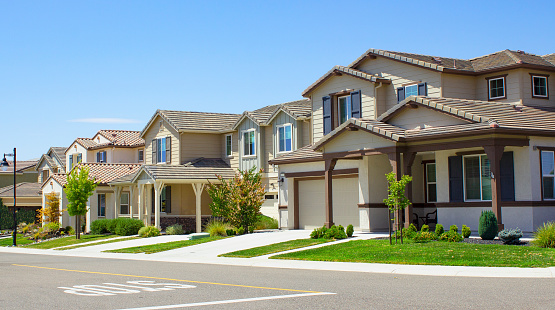

***Imports***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

***EDA - EXPLORATORY DATA ANALYSIS***

***Data Collection***

In [ ]:
# Reading the input file
df_train = pd.read_csv('/kaggle/input/playground-series-s3e1/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s3e1/test.csv')

> # ***TRAIN & TEST DATA ANALYSIS***

***Analyzing the Data***

In [ ]:
df_train.head()   # displays the first five rows of the dataframe

In [ ]:
df_test.head()   # displays the first five rows of the dataframe

In [ ]:
df_train.shape    # returns a tuple of array dimension that specifies the number of rows and columns

In [ ]:
df_test.shape    # returns a tuple of array dimension that specifies the number of rows and columns

In [ ]:
df_train.info()   # prints the information about the dataframe

In [ ]:
df_test.info()   # prints the information about the dataframe

***Check for missing values and handle them.***

In [ ]:
df_train.isnull().sum()

In [ ]:
df_test.isna().sum()

***Check for duplicate values***

In [ ]:
df_train.duplicated().any()

In [ ]:
df_test.duplicated().any()

***Check for outliers. If present try to handle them. (Train Data)***

In [ ]:
df_train.skew()

In [ ]:
from scipy.stats import skew
for column in df_train:
    print(column)
    print(f"Skewness: {skew(df_train[column])}")
    plt.figure(figsize=(3,3))
    plt.style.use('ggplot')
    sns.distplot(df_train[column])
    plt.grid(False)
    plt.show()

***Handling Skewness***

In [ ]:
# Interquantile Range
quantile1=df_train["AveBedrms"].quantile(0.25)
quantile2=df_train["AveBedrms"].quantile(0.75)

In [ ]:
df_train["AveBedrms"]=np.where(df_train["AveBedrms"]<quantile1,quantile1,df_train["AveBedrms"])
df_train["AveBedrms"]=np.where(df_train["AveBedrms"]>quantile2,quantile2,df_train["AveBedrms"])

In [ ]:
a = round(df_train['AveBedrms'].skew(),6)
print(a)

In [ ]:
# Interquantile Range
quantile1=df_train["MedInc"].quantile(0.25)
quantile2=df_train["MedInc"].quantile(0.75)

In [ ]:
df_train["MedInc"]=np.where(df_train["MedInc"]<quantile1,quantile1,df_train["MedInc"])
df_train["MedInc"]=np.where(df_train["MedInc"]>quantile2,quantile2,df_train["MedInc"])

In [ ]:
b = round(df_train['MedInc'].skew(),6)
print(b)

In [ ]:
# Interquantile Range
quantile1=df_train["AveOccup"].quantile(0.25)
quantile2=df_train["AveOccup"].quantile(0.75)

In [ ]:
df_train["AveOccup"]=np.where(df_train["AveOccup"]<quantile1,quantile1,df_train["AveOccup"])
df_train["AveOccup"]=np.where(df_train["AveOccup"]>quantile2,quantile2,df_train["AveOccup"])

In [ ]:
c = round(df_train['AveOccup'].skew(),6)
print(c)

In [ ]:
# Interquantile Range
quantile1=df_train["AveRooms"].quantile(0.25)
quantile2=df_train["AveRooms"].quantile(0.75)

In [ ]:
df_train["AveRooms"]=np.where(df_train["AveRooms"]<quantile1,quantile1,df_train["AveRooms"])
df_train["AveRooms"]=np.where(df_train["AveRooms"]>quantile2,quantile2,df_train["AveRooms"])

In [ ]:
d = round(df_train['AveRooms'].skew(),6)
print(d)

In [ ]:
# Interquantile Range
quantile1=df_train["Population"].quantile(0.25)
quantile2=df_train["Population"].quantile(0.75)

In [ ]:
df_train["Population"]=np.where(df_train["Population"]<quantile1,quantile1,df_train["Population"])
df_train["Population"]=np.where(df_train["Population"]>quantile2,quantile2,df_train["Population"])

In [ ]:
e = round(df_train['Population'].skew(),6)
print(e)

In [ ]:
# Interquantile Range
quantile1=df_train["MedHouseVal"].quantile(0.25)
quantile2=df_train["MedHouseVal"].quantile(0.75)

In [ ]:
df_train["MedHouseVal"]=np.where(df_train["MedHouseVal"]<quantile1,quantile1,df_train["MedHouseVal"])
df_train["MedHouseVal"]=np.where(df_train["MedHouseVal"]>quantile2,quantile2,df_train["MedHouseVal"])

In [ ]:
f = round(df_train['MedHouseVal'].skew(),6)
print(f)

***After reducing skewness...***

In [ ]:
df_train.skew()

***Transformation of Target***

In [ ]:
fig,ax = plt.subplots(figsize=(3,3))
sns.histplot(np.log(df_train['MedHouseVal']))
plt.show()

***Correlation (Train Data)***

In [ ]:
correlation = df_train.corr()
correlation

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='crest',linewidths=0.2)
plt.show()

***Check for outliers. If present try to handle them. (Test Data)***

In [ ]:
df_test.skew()

***Handling Skewness***

In [ ]:
# Interquantile Range
quantile1=df_test["AveBedrms"].quantile(0.25)
quantile2=df_test["AveBedrms"].quantile(0.75)

In [ ]:
df_test["AveBedrms"]=np.where(df_test["AveBedrms"]<quantile1,quantile1,df_test["AveBedrms"])
df_test["AveBedrms"]=np.where(df_test["AveBedrms"]>quantile2,quantile2,df_test["AveBedrms"])

In [ ]:
a = round(df_test['AveBedrms'].skew(),6)
print(a)

In [ ]:
# Interquantile Range
quantile1=df_test["AveOccup"].quantile(0.25)
quantile2=df_test["AveOccup"].quantile(0.75)

In [ ]:
df_test["AveOccup"]=np.where(df_test["AveOccup"]<quantile1,quantile1,df_test["AveOccup"])
df_test["AveOccup"]=np.where(df_test["AveOccup"]>quantile2,quantile2,df_test["AveOccup"])

In [ ]:
b = round(df_test['AveOccup'].skew(),6)
print(b)

In [ ]:
# Interquantile Range
quantile1=df_test["AveRooms"].quantile(0.25)
quantile2=df_test["AveRooms"].quantile(0.75)

In [ ]:
df_test["AveRooms"]=np.where(df_test["AveRooms"]<quantile1,quantile1,df_test["AveRooms"])
df_test["AveRooms"]=np.where(df_test["AveRooms"]>quantile2,quantile2,df_test["AveRooms"])

In [ ]:
c = round(df_test['AveRooms'].skew(),6)
print(c)

In [ ]:
# Interquantile Range
quantile1=df_test["Population"].quantile(0.25)
quantile2=df_test["Population"].quantile(0.75)

In [ ]:
df_test["Population"]=np.where(df_test["Population"]<quantile1,quantile1,df_test["Population"])
df_test["Population"]=np.where(df_test["Population"]>quantile2,quantile2,df_test["Population"])

In [ ]:
d = round(df_test['Population'].skew(),6)
print(d)

In [ ]:
# Interquantile Range
quantile1=df_test["MedInc"].quantile(0.25)
quantile2=df_test["MedInc"].quantile(0.75)

In [ ]:
df_test["MedInc"]=np.where(df_test["MedInc"]<quantile1,quantile1,df_test["MedInc"])
df_test["MedInc"]=np.where(df_test["MedInc"]>quantile2,quantile2,df_test["MedInc"])

In [ ]:
e = round(df_test['MedInc'].skew(),6)
print(e)

***After reducing skewness...***

In [ ]:
df_test.skew()

***Correlation (Test Data)***

In [ ]:
correlation = df_test.corr()
correlation

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='crest',linewidths=0.2)
plt.show()

***Splitting the Data***

In [ ]:
X_train = df_train.iloc[:,1:9]
X_train.head(2)

In [ ]:
y_train = df_train.MedHouseVal
y_train.head(2)

In [ ]:
X_test = df_test.iloc[:,1:]
X_test.head(2)

# ***MODELLING***

> ***A voting regressor is an ensemble meta-estimator that fits several base regressors, each on the whole dataset. Then it averages the individual predictions to form a final prediction.***

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
reg1 = GradientBoostingRegressor(random_state=1)

from sklearn.ensemble import RandomForestRegressor
reg2 = RandomForestRegressor(random_state=1)

from sklearn.linear_model import LinearRegression
reg3 = LinearRegression()

from sklearn.ensemble import VotingRegressor
regressor = VotingRegressor(estimators=[('gb', reg1), ('rf', reg2), ('lir', reg3)])

regressor.fit(X_train, y_train)
prediction = regressor.predict(X_test)
prediction

In [ ]:
submission = pd.DataFrame({'id': df_test.id, 'MedHouseVal': prediction})
submission.head()

In [ ]:
submission.to_csv('submission.csv', index=False)